In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
DATASET_PATH = "utkFace_Age_Dataset/UTKFace"

print("Total Images :", len(os.listdir(DATASET_PATH)))

Total Images : 23708


In [3]:
data = []

for file in os.listdir(DATASET_PATH):

    try:

        age = int(file.split("_")[0])

        image_path = os.path.join(DATASET_PATH, file)

        data.append([image_path, age])

    except:
        continue

df = pd.DataFrame(data, columns=["image_path", "age"])

df.head()

,image_path,age
0,utkFace_Age_Dataset/UTKFace\100_0_0_2017011221...,100
1,utkFace_Age_Dataset/UTKFace\100_0_0_2017011221...,100
2,utkFace_Age_Dataset/UTKFace\100_1_0_2017011018...,100
3,utkFace_Age_Dataset/UTKFace\100_1_0_2017011221...,100
4,utkFace_Age_Dataset/UTKFace\100_1_0_2017011221...,100


In [4]:
print(df.shape)

df.info()

df.describe()

(23708, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23708 entries, 0 to 23707
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  23708 non-null  object
 1   age         23708 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 370.6+ KB


,age
count,23708.000000
mean,33.303484
std,19.886112
min,1.000000
25%,23.000000
50%,29.000000
75%,45.000000
max,116.000000


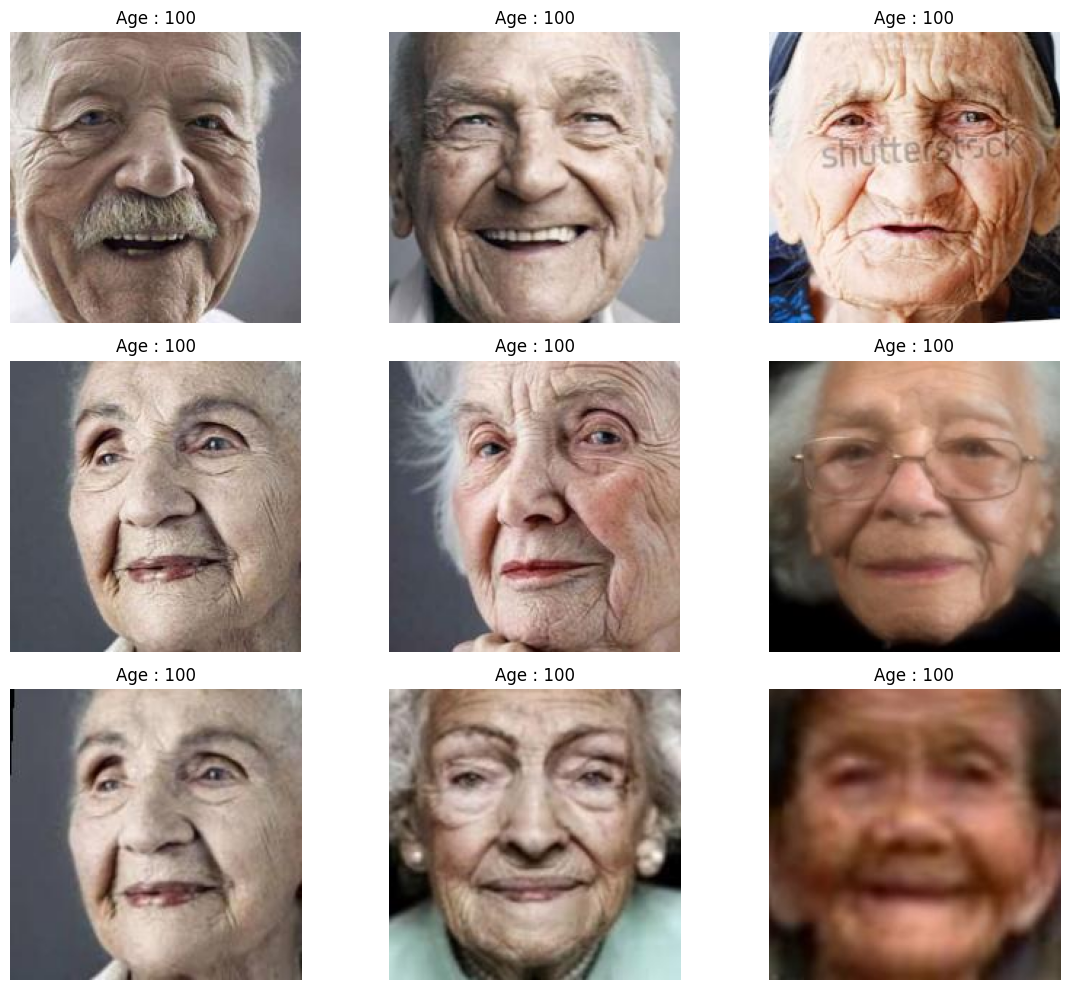

In [5]:
plt.figure(figsize=(12,10))

for i in range(9):

    img = cv2.imread(df.iloc[i]["image_path"])

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    age = df.iloc[i]["age"]

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(f"Age : {age}")

    plt.axis("off")

plt.tight_layout()

plt.show()

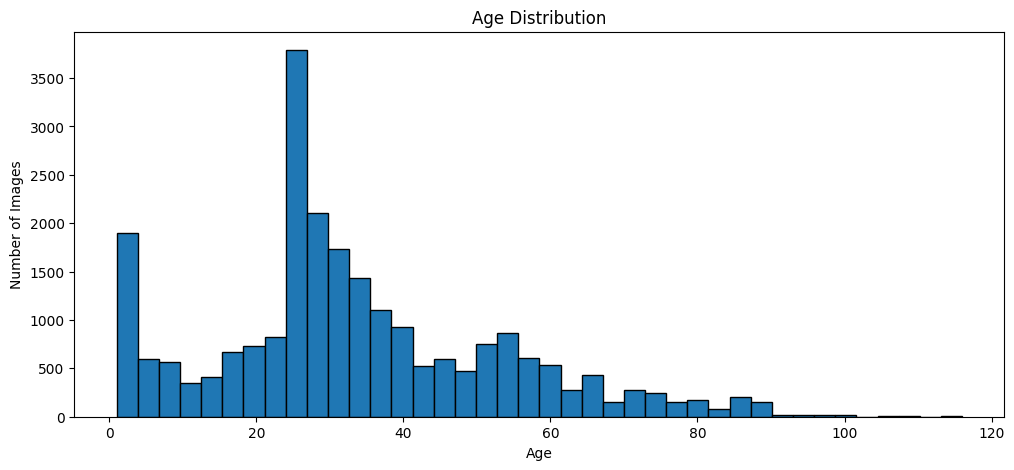

In [6]:
plt.figure(figsize=(12,5))

plt.hist(df["age"], bins=40, edgecolor="black")

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Number of Images")

plt.show()

In [7]:
print(df["age"].value_counts().sort_index())

age
1      1123
2       482
3       289
4       273
5       196
       ... 
105       5
110       5
111       1
115       3
116       4
Name: count, Length: 104, dtype: int64


In [10]:
def age_to_group(age):

    if age <= 5:
        return "0-5"
    elif age <= 10:
        return "6-10"
    elif age <= 15:
        return "11-15"
    elif age <= 20:
        return "16-20"
    elif age <= 30:
        return "21-30"
    elif age <= 40:
        return "31-40"
    elif age <= 50:
        return "41-50"
    elif age <= 60:
        return "51-60"
    elif age <= 70:
        return "61-70"
    elif age <= 80:
        return "71-80"
    else:
        return "81+"

In [11]:
df["age_group"] = df["age"].apply(age_to_group)

In [12]:
print(df["age_group"].value_counts())

age_group
21-30    7784
31-40    4339
0-5      2363
51-60    2211
41-50    2100
61-70    1172
16-20    1049
6-10      855
71-80     685
11-15     610
81+       540
Name: count, dtype: int64


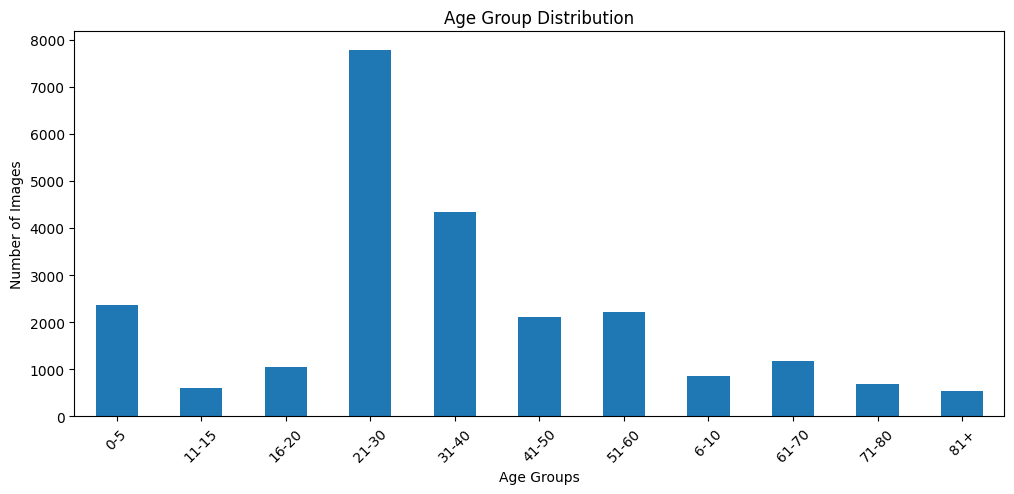

In [13]:
plt.figure(figsize=(12,5))

df["age_group"].value_counts().sort_index().plot(kind="bar")

plt.title("Age Group Distribution")

plt.xlabel("Age Groups")

plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

In [14]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["age_group"]
)

print("Training Samples :", len(train_df))
print("Validation Samples :", len(val_df))

Training Samples : 18966
Validation Samples : 4742


In [15]:
IMAGE_SIZE = (160, 160)

BATCH_SIZE = 16

In [16]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=15,

    zoom_range=0.2,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [17]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="age_group",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="age_group",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 18966 validated image filenames belonging to 11 classes.
Found 4742 validated image filenames belonging to 11 classes.


In [18]:
print(train_generator.class_indices)

{'0-5': 0, '11-15': 1, '16-20': 2, '21-30': 3, '31-40': 4, '41-50': 5, '51-60': 6, '6-10': 7, '61-70': 8, '71-80': 9, '81+': 10}


In [19]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(160,160,3)
)

base_model.trainable = False

In [20]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Input
)
from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

output = Dense(
    len(train_generator.class_indices),
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

In [21]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 160, 160, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 80, 80, 32)        │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 80, 80, 32)        │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 80, 80, 32)        │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 80, 80, 32)        │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 80, 80, 32)        │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 80, 80, 32)        │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 80, 80, 16)        │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 80, 80, 16)        │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 80, 80, 96)        │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 80, 80, 96)        │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 80, 80, 96)        │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 81, 81, 96)        │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 40, 40, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,272,075 (8.67 MB)

 Trainable params: 14,091 (55.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

os.makedirs("models", exist_ok=True)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "models/age_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [24]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/10
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.2804 - loss: 2.2286
Epoch 1: val_accuracy improved from None to 0.40173, saving model to models/age_model.keras

Epoch 1: finished saving model to models/age_model.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 1165s 975ms/step - accuracy: 0.3248 - loss: 2.0341 - val_accuracy: 0.4017 - val_loss: 1.6841
Epoch 2/10
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.3881 - loss: 1.7727
Epoch 2: val_accuracy improved from 0.40173 to 0.42872, saving model to models/age_model.keras

Epoch 2: finished saving model to models/age_model.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 1007s 849ms/step - accuracy: 0.3968 - loss: 1.7426 - val_accuracy: 0.4287 - val_loss: 1.5776
Epoch 3/10
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.4114 - loss: 1.6520
Epoch 3: val_accuracy improved from 0.42872 to 0.45065, saving model to models/age_model.keras

Epoch 3: finished saving model to models/age_model.keras
1186/1186 ━━━━━━━━━━━━━━━━

In [25]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

297/297 ━━━━━━━━━━━━━━━━━━━━ 124s 419ms/step - accuracy: 0.4749 - loss: 1.4245
Validation Loss : 1.4244550466537476
Validation Accuracy : 0.4749051034450531


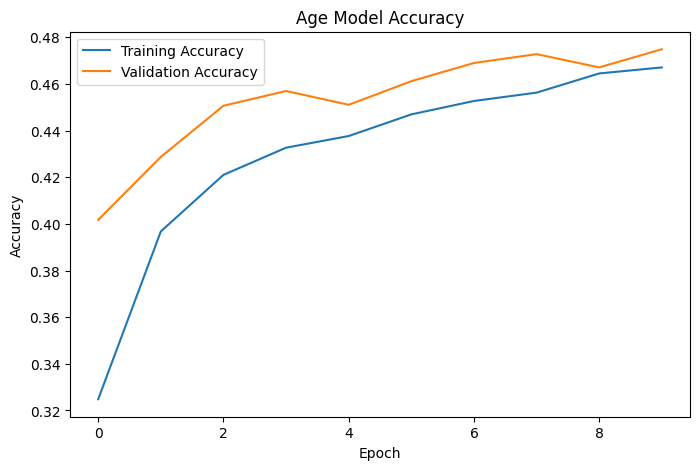

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Age Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

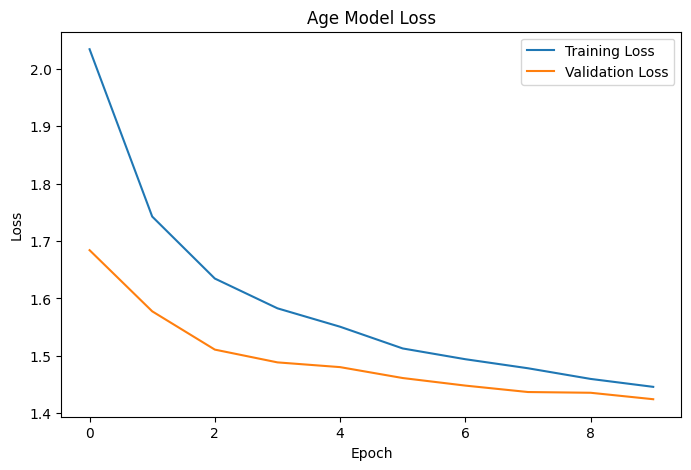

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Age Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [28]:
import os

os.makedirs("models", exist_ok=True)

model.save("models/age_model.keras")

print("Age Model Saved Successfully!")

Age Model Saved Successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


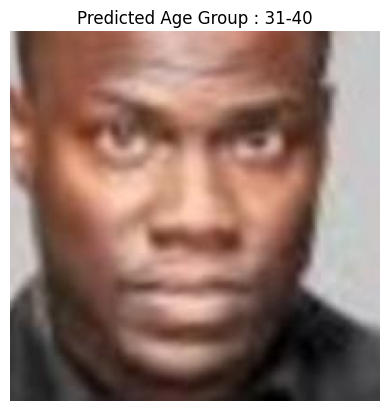

In [29]:
import random

random_image = random.choice(val_df["image_path"].tolist())

img = cv2.imread(random_image)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_img = cv2.resize(img_rgb, (160,160))
input_img = input_img.astype("float32") / 255.0
input_img = np.expand_dims(input_img, axis=0)

prediction = model.predict(input_img)

class_names = list(train_generator.class_indices.keys())

predicted_age_group = class_names[np.argmax(prediction)]

plt.imshow(img_rgb)
plt.title(f"Predicted Age Group : {predicted_age_group}")
plt.axis("off")

plt.show()

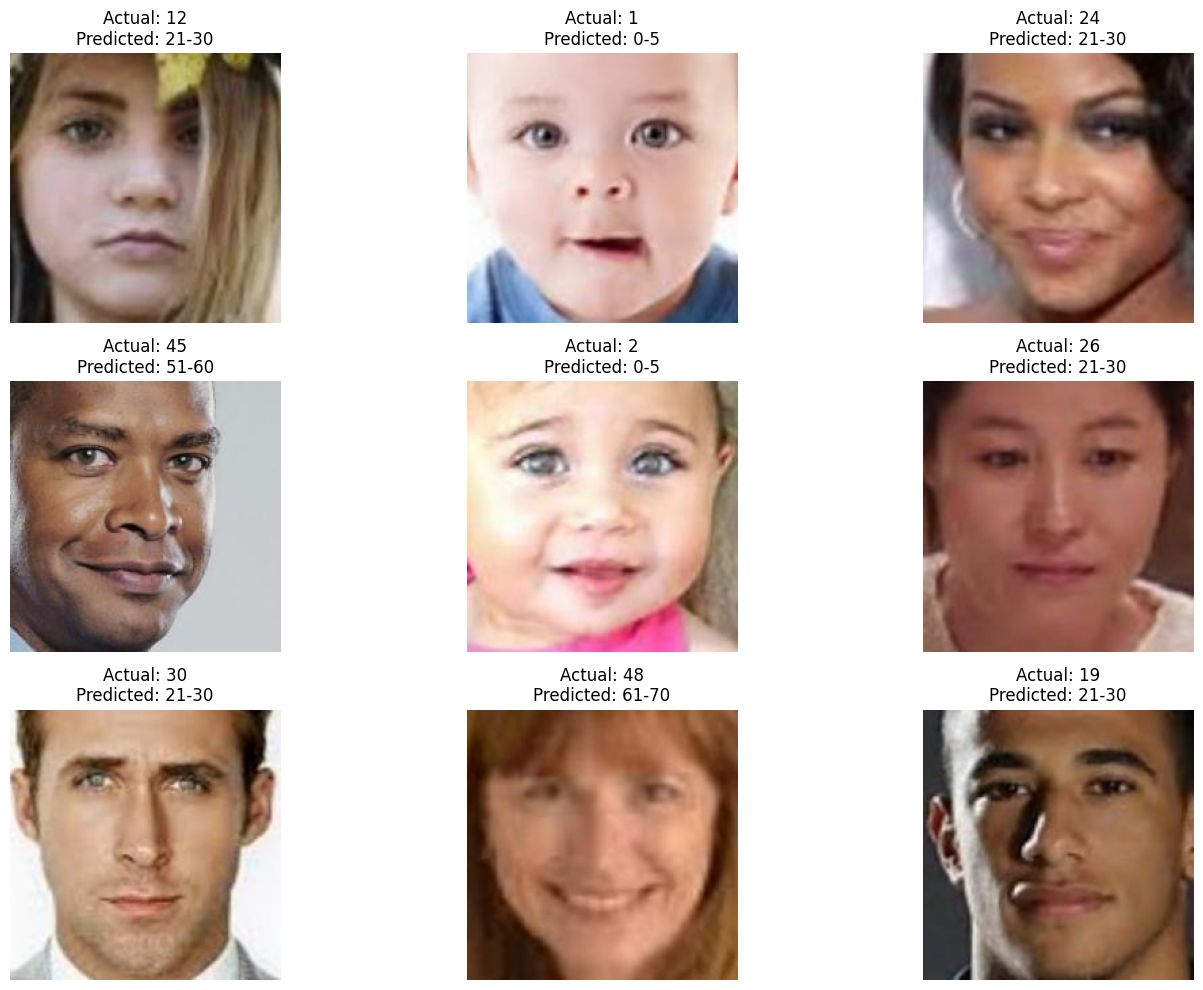

In [30]:
plt.figure(figsize=(15,10))

samples = val_df.sample(9, random_state=42)

for i, (_, row) in enumerate(samples.iterrows()):

    img = cv2.imread(row["image_path"])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    input_img = cv2.resize(img_rgb, (128,128))
    input_img = input_img.astype("float32") / 255.0
    input_img = np.expand_dims(input_img, axis=0)

    prediction = model.predict(input_img, verbose=0)

    predicted = class_names[np.argmax(prediction)]

    plt.subplot(3,3,i+1)
    plt.imshow(img_rgb)
    plt.title(f"Actual: {row['age']}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
from sklearn.metrics import classification_report

predictions = model.predict(val_generator, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(train_generator.class_indices.keys())
))

297/297 ━━━━━━━━━━━━━━━━━━━━ 71s 232ms/step
              precision    recall  f1-score   support

         0-5       0.87      0.77      0.82       473
       11-15       0.26      0.14      0.18       122
       16-20       0.41      0.12      0.18       210
       21-30       0.52      0.84      0.64      1557
       31-40       0.31      0.21      0.25       868
       41-50       0.26      0.10      0.15       420
       51-60       0.31      0.34      0.32       442
        6-10       0.39      0.27      0.32       171
       61-70       0.30      0.26      0.28       234
       71-80       0.14      0.04      0.06       137
         81+       0.48      0.48      0.48       108

    accuracy                           0.47      4742
   macro avg       0.39      0.32      0.34      4742
weighted avg       0.44      0.47      0.43      4742

